In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = r"Wave_direction_2016_2025.nc"

ds = xr.open_dataset(file)

print(ds)
print("Variables:", list(ds.data_vars))
print("Start time:", pd.to_datetime(ds["valid_time"].values).min())
print("End time:", pd.to_datetime(ds["valid_time"].values).max())
print("Latitudes:", ds["latitude"].values)
print("Longitudes:", ds["longitude"].values)

<xarray.Dataset> Size: 906kB
Dimensions:     (valid_time: 15102, latitude: 3, longitude: 3)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 121kB 2016-01-01 ... 2026-05-03T0...
    expver      (valid_time) <U4 242kB ...
  * latitude    (latitude) float64 24B 13.0 12.5 12.0
  * longitude   (longitude) float64 24B 43.0 43.5 44.0
    number      int64 8B ...
Data variables:
    mwd         (valid_time, latitude, longitude) float32 544kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-08T10:05 GRIB to CDM+CF via cfgrib-0.9.1...
Variables: ['mwd']
Start time: 2016-01-01 00:00:00
End time: 2026-05-03 06:00:00
Latitudes: [13.  12.5 12. ]
Longitudes: [43.  43.5 44. ]


In [2]:
# Approximate location from your wind file name
target_lat = 12.591365
target_lon = 43.345936

# Select nearest grid point
wave_point = ds.sel(
    latitude=target_lat,
    longitude=target_lon,
    method="nearest"
)

print("Selected latitude:", float(wave_point["latitude"].values))
print("Selected longitude:", float(wave_point["longitude"].values))

Selected latitude: 12.5
Selected longitude: 43.5


In [3]:
wave = wave_point[["mwd"]].to_dataframe().reset_index()

# Rename columns
wave = wave.rename(columns={
    "valid_time": "datetime",
    "mwd": "MWD"
})

# Convert datetime
wave["datetime"] = pd.to_datetime(wave["datetime"])

# Remove missing values
wave = wave.dropna(subset=["MWD"])

# Optional: keep only 2016-2025
wave = wave[
    (wave["datetime"] >= "2016-01-01") &
    (wave["datetime"] <= "2025-12-31 23:59")
]

# Add year and month
wave["year"] = wave["datetime"].dt.year
wave["month"] = wave["datetime"].dt.month
wave["month_name"] = wave["datetime"].dt.month_name()

print(wave.head())
print("Number of records:", len(wave))
print("Start:", wave["datetime"].min())
print("End:", wave["datetime"].max())

             datetime         MWD  number  latitude  longitude expver  year  \
0 2016-01-01 00:00:00  111.586014       0      12.5       43.5   0001  2016   
1 2016-01-01 06:00:00  109.276855       0      12.5       43.5   0001  2016   
2 2016-01-01 12:00:00  115.025528       0      12.5       43.5   0001  2016   
3 2016-01-01 18:00:00  117.650818       0      12.5       43.5   0001  2016   
4 2016-01-02 00:00:00  111.118790       0      12.5       43.5   0001  2016   

   month month_name  
0      1    January  
1      1    January  
2      1    January  
3      1    January  
4      1    January  
Number of records: 14612
Start: 2016-01-01 00:00:00
End: 2025-12-31 18:00:00


In [4]:
def compass_direction(deg):
    directions = [
        "N", "NNE", "NE", "ENE",
        "E", "ESE", "SE", "SSE",
        "S", "SSW", "SW", "WSW",
        "W", "WNW", "NW", "NNW"
    ]
    index = int((deg + 11.25) % 360 / 22.5)
    return directions[index]


def circular_mean_direction(direction_deg):
    direction_deg = direction_deg.dropna()
    
    if len(direction_deg) == 0:
        return np.nan
    
    direction_rad = np.deg2rad(direction_deg)
    
    x = np.mean(np.sin(direction_rad))
    y = np.mean(np.cos(direction_rad))
    
    mean_direction = np.rad2deg(np.arctan2(x, y))
    mean_direction = (mean_direction + 360) % 360
    
    return mean_direction


def direction_consistency(direction_deg):
    direction_deg = direction_deg.dropna()
    
    if len(direction_deg) == 0:
        return np.nan
    
    direction_rad = np.deg2rad(direction_deg)
    
    x = np.mean(np.sin(direction_rad))
    y = np.mean(np.cos(direction_rad))
    
    R = np.sqrt(x**2 + y**2)
    return R

In [5]:
monthly_wave_direction = wave.groupby(["month", "month_name"]).agg(
    mean_MWD=("MWD", circular_mean_direction),
    direction_consistency=("MWD", direction_consistency),
    number_of_records=("MWD", "count")
).reset_index()

monthly_wave_direction = monthly_wave_direction.sort_values("month")

monthly_wave_direction["mean_compass_direction"] = monthly_wave_direction["mean_MWD"].apply(compass_direction)

print(monthly_wave_direction)

    month month_name    mean_MWD  direction_consistency  number_of_records  \
0       1    January  111.066498               0.891973               1240   
1       2   February  108.611877               0.876887               1132   
2       3      March  109.584503               0.846891               1240   
3       4      April  110.223633               0.894855               1200   
4       5        May  108.035461               0.506758               1240   
5       6       June  323.018127               0.121304               1200   
6       7       July  300.793304               0.629812               1240   
7       8     August  296.350464               0.553421               1240   
8       9  September   45.258087               0.090520               1200   
9      10    October  115.168701               0.883111               1240   
10     11   November  114.740356               0.979446               1200   
11     12   December  114.008667               0.965045         

In [6]:
def dominant_direction_sector(direction_series):
    sectors = direction_series.dropna().apply(compass_direction)
    
    if len(sectors) == 0:
        return np.nan
    
    return sectors.value_counts().idxmax()


def dominant_direction_percentage(direction_series):
    sectors = direction_series.dropna().apply(compass_direction)
    
    if len(sectors) == 0:
        return np.nan
    
    return sectors.value_counts(normalize=True).max() * 100


monthly_dominant_direction = wave.groupby(["month", "month_name"]).agg(
    dominant_direction=("MWD", dominant_direction_sector),
    dominant_direction_frequency_percent=("MWD", dominant_direction_percentage)
).reset_index()

monthly_dominant_direction = monthly_dominant_direction.sort_values("month")

print(monthly_dominant_direction)

    month month_name dominant_direction  dominant_direction_frequency_percent
0       1    January                ESE                             80.080645
1       2   February                ESE                             81.007067
2       3      March                ESE                             75.645161
3       4      April                ESE                             77.166667
4       5        May                ESE                             46.693548
5       6       June                 NW                             40.000000
6       7       July                 NW                             53.387097
7       8     August                 NW                             44.354839
8       9  September                 NW                             30.333333
9      10    October                ESE                             66.935484
10     11   November                ESE                             79.500000
11     12   December                ESE                         

In [7]:
monthly_wave_table = monthly_wave_direction.merge(
    monthly_dominant_direction,
    on=["month", "month_name"]
)

monthly_wave_table = monthly_wave_table[[
    "month",
    "month_name",
    "mean_MWD",
    "mean_compass_direction",
    "direction_consistency",
    "dominant_direction",
    "dominant_direction_frequency_percent",
    "number_of_records"
]]

print(monthly_wave_table)

    month month_name    mean_MWD mean_compass_direction  \
0       1    January  111.066498                    ESE   
1       2   February  108.611877                    ESE   
2       3      March  109.584503                    ESE   
3       4      April  110.223633                    ESE   
4       5        May  108.035461                    ESE   
5       6       June  323.018127                     NW   
6       7       July  300.793304                    WNW   
7       8     August  296.350464                    WNW   
8       9  September   45.258087                     NE   
9      10    October  115.168701                    ESE   
10     11   November  114.740356                    ESE   
11     12   December  114.008667                    ESE   

    direction_consistency dominant_direction  \
0                0.891973                ESE   
1                0.876887                ESE   
2                0.846891                ESE   
3                0.894855               

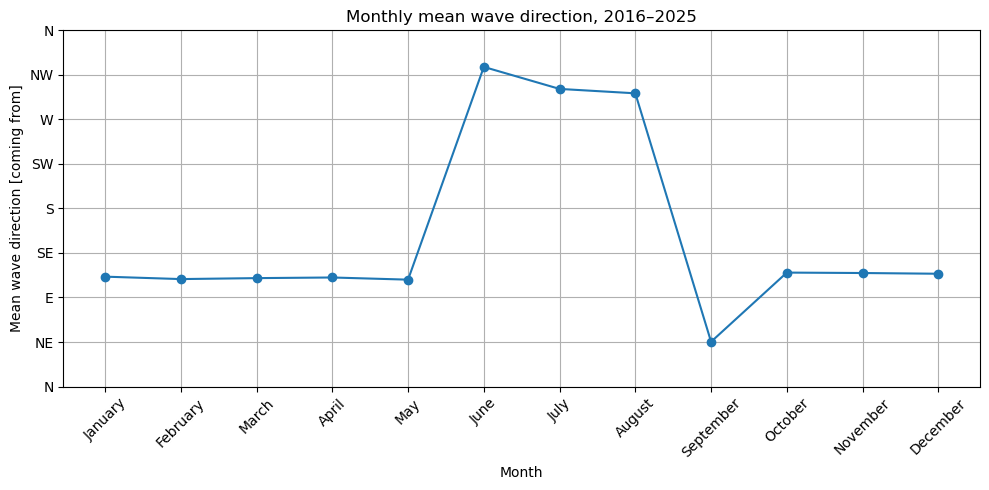

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_wave_table["month_name"],
    monthly_wave_table["mean_MWD"],
    marker="o",
    label="Mean wave direction"
)

plt.xlabel("Month")
plt.ylabel("Mean wave direction [coming from]")
plt.title("Monthly mean wave direction, 2016–2025")
plt.grid(True)

plt.yticks(
    ticks=[0, 45, 90, 135, 180, 225, 270, 315, 360],
    labels=["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

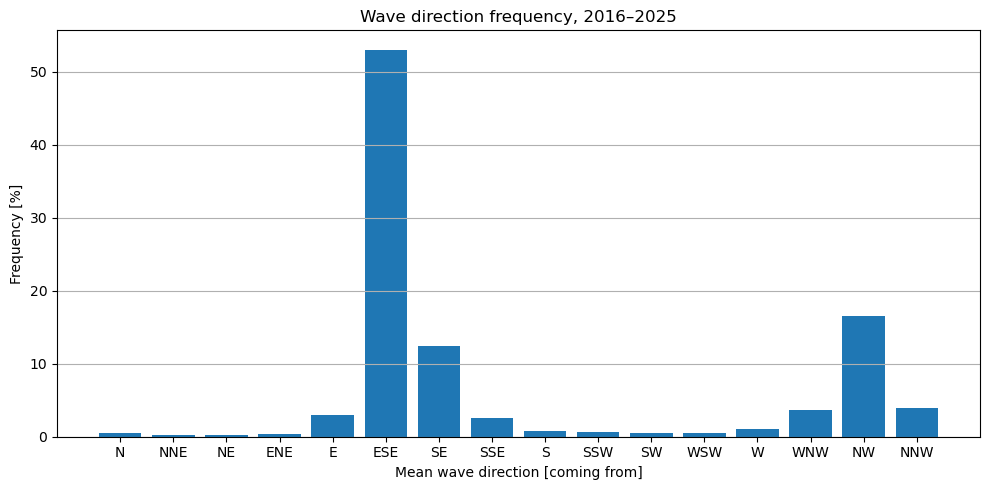

direction_sector
N       0.533808
NNE     0.191623
NE      0.246373
ENE     0.376403
E       3.004380
ESE    53.004380
SE     12.359704
SSE     2.621133
S       0.780181
SSW     0.581714
SW      0.506433
WSW     0.533808
W       1.040241
WNW     3.709280
NW     16.520668
NNW     3.989871
Name: proportion, dtype: float64


In [9]:
wave["direction_sector"] = wave["MWD"].apply(compass_direction)

sector_order = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW"
]

direction_frequency = wave["direction_sector"].value_counts(normalize=True) * 100
direction_frequency = direction_frequency.reindex(sector_order, fill_value=0)

plt.figure(figsize=(10, 5))

plt.bar(direction_frequency.index, direction_frequency.values)

plt.xlabel("Mean wave direction [coming from]")
plt.ylabel("Frequency [%]")
plt.title("Wave direction frequency, 2016–2025")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

print(direction_frequency)

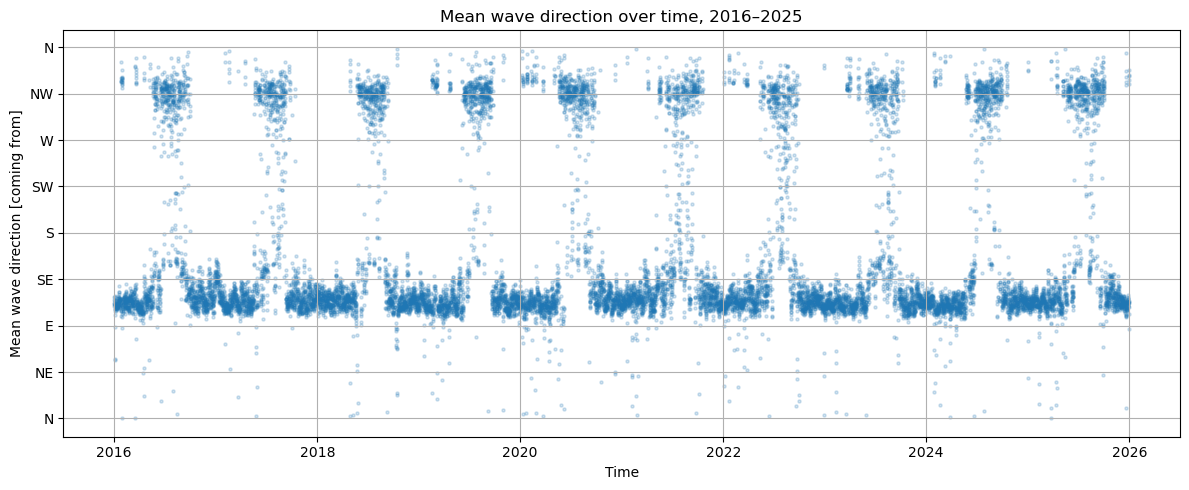

In [10]:
plt.figure(figsize=(12, 5))

plt.scatter(wave["datetime"], wave["MWD"], alpha=0.2, s=5)

plt.xlabel("Time")
plt.ylabel("Mean wave direction [coming from]")
plt.title("Mean wave direction over time, 2016–2025")

plt.yticks(
    ticks=[0, 45, 90, 135, 180, 225, 270, 315, 360],
    labels=["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
)

plt.grid(True)
plt.tight_layout()
plt.show()